### Tile Coding Feature Representation

To handle the continuous state space of MountainCar, I implemented tile coding as a function approximation method. The state consists of position and velocity, both continuous variables, which makes tabular representation infeasible.

Tile coding works by dividing the state space into multiple overlapping grids called *tilings*. Each tiling partitions the space into discrete tiles, and each tiling is slightly offset from the others. This ensures that nearby states share some features but are not identical.

For a given state:
- Each tiling activates exactly one tile
- The active tiles are mapped to feature indices
- The final feature vector is sparse, with only `num_tilings` active features

This provides:
- **Generalization**: nearby states share features
- **Efficiency**: only a small number of weights are updated per step
- **Flexibility**: controlled by number of tilings and tile resolution

In [21]:
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym   

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 12

In [22]:
class TileCoder:
    def __init__(self, num_tilings, tiles_per_dim, state_bounds):
        self.n_tilings = int(num_tilings)
        self.tiles_shape = np.array(tiles_per_dim, dtype=int)
        self.bounds = np.array(state_bounds, dtype=float)

        self.dim = len(tiles_per_dim)

        span = self.bounds[:, 1] - self.bounds[:, 0]
        self.tile_size = span / self.tiles_shape

        self.tiles_per_layer = int(np.prod(self.tiles_shape))
        self.total_features = self.tiles_per_layer * self.n_tilings

        # Offsets for each tiling
        self.offsets = [
            (i / self.n_tilings) * self.tile_size
            for i in range(self.n_tilings)
        ]

    def get_active_tiles(self, state):
        active_tiles = []

        for tiling, offset in enumerate(self.offsets):
            shifted = state + offset
            ratios = (shifted - self.bounds[:, 0]) / self.tile_size
            coords = np.floor(ratios).astype(int)

            coords = np.clip(coords, 0, self.tiles_shape - 1)

            tile_index = np.ravel_multi_index(coords, self.tiles_shape)
            global_index = tiling * self.tiles_per_layer + tile_index

            active_tiles.append(global_index)

        return active_tiles

    def get_feature_vector(self, state):
        features = np.zeros(self.total_features)
        active = self.get_active_tiles(state)
        features[active] = 1
        return features

In [ ]:
bounds = [(-1.2, 0.6), (-0.07, 0.07)]  

tc = TileCoder(num_tilings=8, tiles_per_dim=[8, 8], state_bounds=bounds)

sample_state = np.array([0.0, 0.0])
feat_vec = tc.get_feature_vector(sample_state)

print("Total features:", tc.total_features)
print("Number of active features:", int(feat_vec.sum()))  # should equal num_tilings
print("Indices of active features:", np.where(feat_vec == 1)[0])

Total features: 512
Number of active features: 8
Indices of active features: [ 44 108 172 236 300 364 436 500]


### Semi-Gradient SARSA with Function Approximation

Instead of storing Q-values in a table, I approximate the action-value function using a linear model:

Q(s, a) = w[a] · x(s)

where:
- w[a] is the weight vector for action a
- x(s) is the feature vector from tile coding

At each step, the weights are updated using the semi-gradient SARSA rule:

w[a] ← w[a] + α (R + γ Q(s', a') − Q(s, a)) x(s)

Key aspects:
- Only weights corresponding to active features are updated
- ε-greedy policy is used for action selection
- Learning is incremental and online

This approach allows learning in continuous state spaces where tabular methods fail.

In [24]:
def run_sarsa_tilecoding(
    env,
    tile_coder,
    num_episodes=500,
    alpha=0.1,
    gamma=1.0,
    eps_start=0.1,
    eps_min=0.01,
    eps_decay=1.0,
    max_steps=1000,
    seed=0,
):
    np.random.seed(seed)

    nA = env.action_space.n
    nF = tile_coder.total_features

    W = np.zeros((nA, nF))

    def compute_q(state, action):
        idx = tile_coder.get_active_tiles(state)
        return W[action, idx].sum()

    def epsilon_greedy(state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(nA)
        q_vals = [compute_q(state, a) for a in range(nA)]
        return int(np.argmax(q_vals))

    ep_lengths = []

    epsilon = eps_start

    for ep in range(num_episodes):
        state, _ = env.reset()
        action = epsilon_greedy(state, epsilon)

        steps = 0

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_action = epsilon_greedy(next_state, epsilon)

            q_current = compute_q(state, action)
            q_next = compute_q(next_state, next_action)

            target = reward + gamma * q_next * (not done)

            active = tile_coder.get_active_tiles(state)
            W[action, active] += alpha * (target - q_current)

            state = next_state
            action = next_action

            steps += 1

            if done:
                break

        ep_lengths.append(steps)

        epsilon = max(eps_min, epsilon * eps_decay)

    return W, ep_lengths

### Baseline Training Results (8×8 tiles, 8 tilings)

In this experiment, the agent was trained for 500 episodes using 8 overlapping tilings, each with an 8×8 grid. The step size α was adjusted to 0.1 / 8, and the exploration rate ε was kept constant at 0.1 throughout training.

At the start, the agent consistently reaches the maximum episode length of 200 steps, indicating that it fails to achieve the goal. As learning progresses, the number of steps per episode begins to decrease, with many episodes completing in roughly 120–160 steps.

The learning curve is somewhat noisy, occasionally jumping back to 200 steps. This behavior is expected in the MountainCar environment due to sparse rewards and the complexity of the value function. Despite these fluctuations, the overall downward trend in episode length suggests that the agent is gradually learning the required strategy of building momentum to reach the goal.

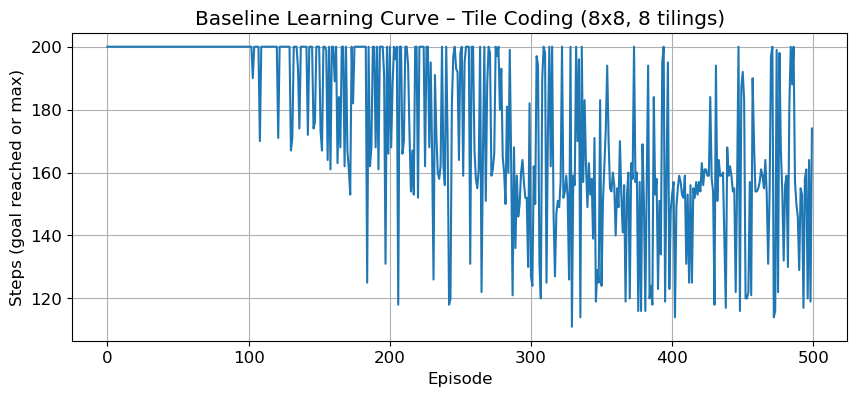

In [25]:
# Initialize environment
environment = gym.make("MountainCar-v0")

# Define bounds and tile coder
bounds = [(-1.2, 0.6), (-0.07, 0.07)]
tc_baseline = TileCoder(
    num_tilings=8,
    tiles_per_dim=[8, 8],
    state_bounds=bounds,
)

# Training parameters
episodes = 500
alpha = 0.1 / tc_baseline.n_tilings   # scaled step size
gamma_val = 1.0
eps_start = 0.1
eps_min = 0.01
eps_decay = 1.0  # no decay

# Train agent
W_base, ep_len_base = run_sarsa_tilecoding(
    environment,
    tc_baseline,
    num_episodes=episodes,
    alpha=alpha,
    gamma=gamma_val,
    eps_start=eps_start,
    eps_min=eps_min,
    eps_decay=eps_decay,
    max_steps=1000,
    seed=42,
)

# Plot results
plt.figure()
plt.plot(ep_len_base)
plt.xlabel("Episode")
plt.ylabel("Steps (goal reached or max)")
plt.title("Baseline Learning Curve – Tile Coding (8x8, 8 tilings)")
plt.grid()
plt.show()

### Evaluating Different Tile Configurations

To study the impact of feature design, I compared three configurations:
1. 4 tilings with 4×4 tiles
2. 8 tilings with 8×8 tiles
3. 16 tilings with 8×8 tiles

Results show clear trade-offs:

- **4×4 tiles (coarse representation)**:
  - Too few tiles → poor resolution
  - Unstable learning
  - Many episodes hit max step limit

- **8×8 tiles (balanced)**:
  - Best performance overall
  - Faster convergence
  - Stable learning behavior

- **16 tilings (high capacity)**:
  - More expressive representation
  - Slower learning due to smaller effective step size
  - No significant improvement over 8 tilings

This highlights the trade-off:
- More tiles → better precision
- But → slower learning and higher computation cost


Evaluating configuration: 4 tilings, 4x4

Evaluating configuration: 8 tilings, 8x8

Evaluating configuration: 16 tilings, 8x8


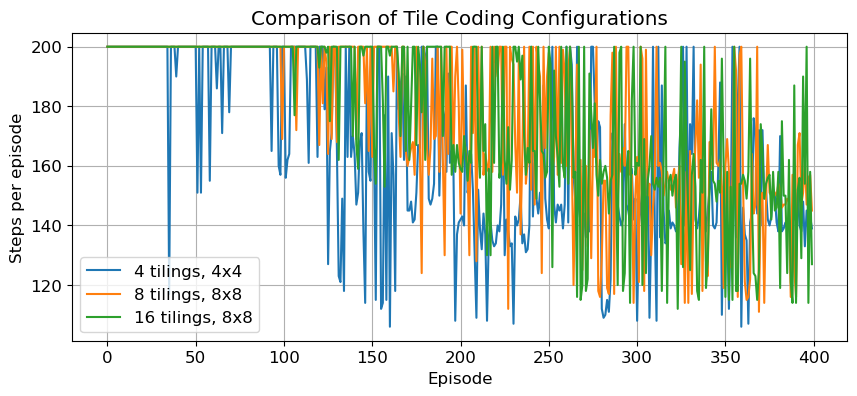

In [26]:
state_bounds = [(-1.2, 0.6), (-0.07, 0.07)]
def evaluate_setting(env, n_tilings, tiles_shape, tag, episodes=500, seed=0):
    coder = TileCoder(
        num_tilings=n_tilings,
        tiles_per_dim=tiles_shape,
        state_bounds=state_bounds
    )

    step_size = 0.1 / n_tilings  # scaling rule

    W, ep_len = run_sarsa_tilecoding(
        env,
        coder,
        num_episodes=episodes,
        alpha=step_size,
        gamma=1.0,
        eps_start=0.1,
        eps_min=0.01,
        eps_decay=0.995,
        max_steps=500,
        seed=seed,
    )

    return coder, W, ep_len, tag


env_eval = gym.make("MountainCar-v0")

configurations = [
    (4,  [4, 4],  "4 tilings, 4x4"),
    (8,  [8, 8],  "8 tilings, 8x8"),
    (16, [8, 8],  "16 tilings, 8x8"),
]

all_results = []

for n_tilings, shape, name in configurations:
    print(f"\nEvaluating configuration: {name}")

    coder_res, W_res, lengths_res, name_res = evaluate_setting(
        env_eval,
        n_tilings,
        shape,
        name,
        episodes=400,
        seed=0
    )

    all_results.append((coder_res, W_res, lengths_res, name_res))


plt.figure()

for _, _, lengths_res, name_res in all_results:
    plt.plot(lengths_res, label=name_res)

plt.xlabel("Episode")
plt.ylabel("Steps per episode")
plt.title("Comparison of Tile Coding Configurations")
plt.legend()
plt.grid()
plt.show()

### Learned Value Function (V(s) = maxₐ Q(s, a))

The value function is computed by taking the maximum action-value at each state:

V(s) = maxₐ Q(s, a)

The heatmap shows how the agent evaluates different states:

- Dark regions (low values):
  - Located in the valley
  - The car lacks momentum to reach the goal

- Brighter regions (higher values):
  - Found near the right hill
  - Indicate states closer to success

The smooth gradient demonstrates that tile coding enables generalization across nearby states. The overall shape matches the known MountainCar value landscape, where the agent must first move away from the goal to gain momentum.


Running experiment: 4 tilings, 4x4

Running experiment: 8 tilings, 8x8

Running experiment: 16 tilings, 8x8


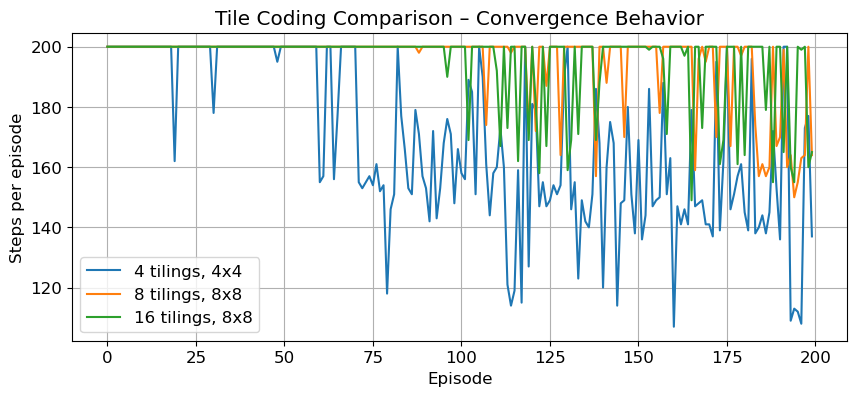

In [29]:
def experiment(env, n_tilings, tiles_shape, name, episodes=500, seed=0):
    coder = TileCoder(
        num_tilings=n_tilings,
        tiles_per_dim=tiles_shape,
        state_bounds=state_bounds
    )

    alpha = 0.1 / n_tilings

    W, ep_len = run_sarsa_tilecoding(
        env,
        coder,
        num_episodes=episodes,
        alpha=alpha,
        gamma=1.0,
        eps_start=0.1,
        eps_min=0.01,
        eps_decay=0.995,
        max_steps=500,
        seed=seed
    )

    return coder, W, ep_len, name


env_eval = gym.make("MountainCar-v0")

configs = [
    (4,  [4, 4],  "4 tilings, 4x4"),
    (8,  [8, 8],  "8 tilings, 8x8"),
    (16, [8, 8],  "16 tilings, 8x8"),
]

outputs = []

for n_tilings, shape, label in configs:
    print(f"\nRunning experiment: {label}")

    coder, W, lengths, label = experiment(
        env_eval,
        n_tilings,
        shape,
        label,
        episodes=200,
        seed=0
    )

    outputs.append((coder, W, lengths, label))


plt.figure()

for _, _, lengths, label in outputs:
    plt.plot(lengths, label=label)

plt.xlabel("Episode")
plt.ylabel("Steps per episode")
plt.title("Tile Coding Comparison – Convergence Behavior")
plt.legend()
plt.grid()
plt.show()

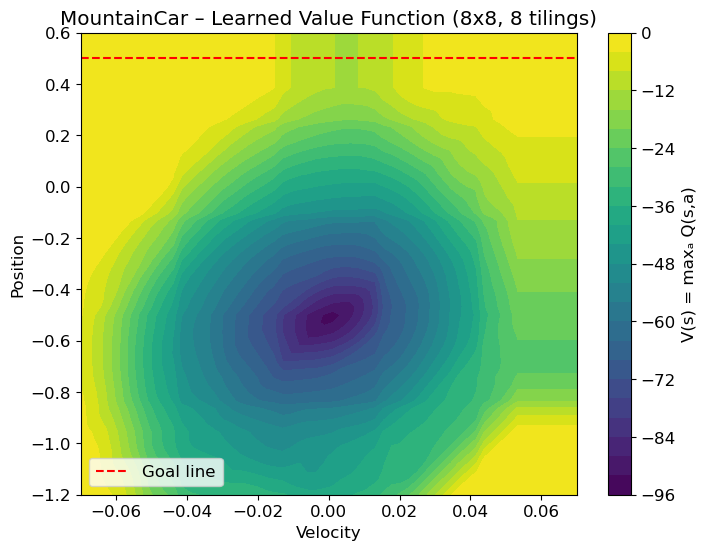

In [30]:
def build_value_grid(W, coder, pos_grid, vel_grid):
    nA = W.shape[0]
    value_map = np.zeros((len(pos_grid), len(vel_grid)))

    for pi, p in enumerate(pos_grid):
        for vi, v in enumerate(vel_grid):
            s = np.array([p, v])
            active_idx = coder.get_active_tiles(s)

            q_vals = np.array([
                W[a, active_idx].sum() for a in range(nA)
            ])

            value_map[pi, vi] = np.max(q_vals)

    return value_map


def visualize_value_function(W, coder, title="Value Function maxₐ Q(s,a)"):
    pos_vals = np.linspace(-1.2, 0.6, 60)
    vel_vals = np.linspace(-0.07, 0.07, 60)

    V = build_value_grid(W, coder, pos_vals, vel_vals)

    plt.figure(figsize=(8, 6))

    contour = plt.contourf(
        vel_vals,
        pos_vals,
        V,
        levels=30,
        cmap="viridis"
    )

    plt.colorbar(contour, label="V(s) = maxₐ Q(s,a)")
    plt.xlabel("Velocity")
    plt.ylabel("Position")
    plt.title(title)

    plt.axhline(0.5, color="red", linestyle="--", label="Goal line")
    plt.legend()
    plt.show()


# Plot for baseline policy
visualize_value_function(
    W_base,
    tc_baseline,
    title="MountainCar – Learned Value Function (8x8, 8 tilings)"
)

In [31]:
def compute_q_grid(W, coder, pos_vals, vel_vals):
    nA = W.shape[0]
    V = np.zeros((len(pos_vals), len(vel_vals)))

    for i, p in enumerate(pos_vals):
        for j, v in enumerate(vel_vals):
            s = np.array([p, v])
            active = coder.get_active_tiles(s)
            q_vals = [W[a, active].sum() for a in range(nA)]
            V[i, j] = np.max(q_vals)

    return V

In [ ]:
def build_policy_grid(W, coder, pos_vals, vel_vals):
    nA = W.shape[0]
    policy_grid = np.zeros((len(pos_vals), len(vel_vals)), dtype=int)

    for pi, p in enumerate(pos_vals):
        for vi, v in enumerate(vel_vals):
            s = np.array([p, v])
            active_idx = coder.get_active_tiles(s)

            q_values = np.array([
                W[a, active_idx].sum() for a in range(nA)
            ])

            policy_grid[pi, vi] = int(np.argmax(q_values))

    return policy_grid


def visualize_policy(W, coder, title="Greedy Policy (State Space)"):
    pos_vals = np.linspace(-1.2, 0.6, 25)
    vel_vals = np.linspace(-0.07, 0.07, 25)

    policy = build_policy_grid(W, coder, pos_vals, vel_vals)

    plt.figure(figsize=(8, 6))

    img = plt.imshow(
        policy,
        origin="lower",
        extent=[vel_vals[0], vel_vals[-1], pos_vals[0], pos_vals[-1]],
        aspect="auto",
        interpolation="nearest",
        cmap="Accent"
    )

    
    cbar = plt.colorbar(img, ticks=[0, 1, 2])
    cbar.ax.set_yticklabels(["Left (0)", "Stay (1)", "Right (2)"])

    plt.xlabel("Velocity")
    plt.ylabel("Position")
    plt.title(title)
    plt.show()

    
    symbol = {0: "←", 1: "·", 2: "→"}

    print("\nSymbolic Policy (rows=position, cols=velocity):")
    for row in policy:
        print(" ".join(symbol[a] for a in row))

[DEBUG] W_base exists: True
[DEBUG] weights_baseline exists: False
[DEBUG] tc_baseline exists: True
[DEBUG] baseline_tile_coder exists: False


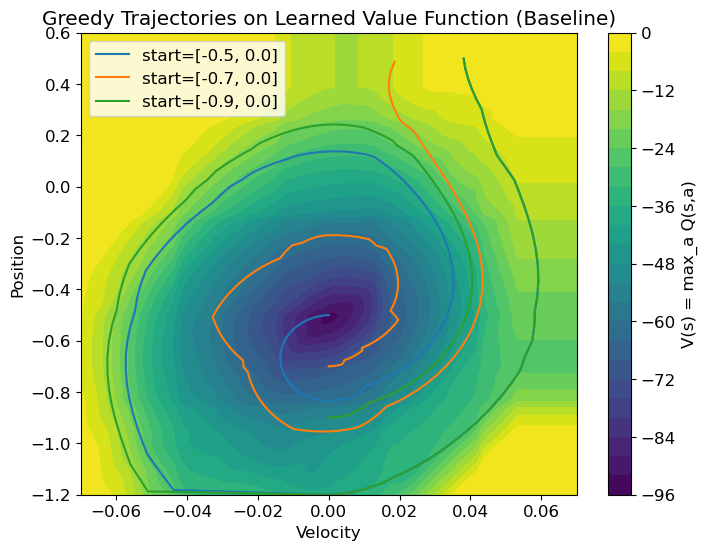

In [ ]:
# =========================
# GREEDY EPISODE
# =========================
def run_greedy_episode(env, weights, tile_coder, start_state=None, max_steps=500):
    n_actions = weights.shape[0]

    state, _ = env.reset()

    if start_state is not None:
        env.unwrapped.state = np.array(start_state, dtype=float)
        state = np.array(start_state, dtype=float)

    positions, velocities = [], []

    done = False
    steps = 0

    while not done and steps < max_steps:
        positions.append(state[0])
        velocities.append(state[1])

        active = tile_coder.get_active_tiles(state)
        q_vals = [weights[a, active].sum() for a in range(n_actions)]
        action = int(np.argmax(q_vals))

        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    return np.array(positions), np.array(velocities)


# =========================
# VALUE GRID (V(s) = max_a Q)
# =========================
def compute_q_grid(weights, tile_coder, positions, velocities):
    n_actions = weights.shape[0]
    V = np.zeros((len(positions), len(velocities)))

    for i, pos in enumerate(positions):
        for j, vel in enumerate(velocities):
            state = np.array([pos, vel])
            active = tile_coder.get_active_tiles(state)

            q_vals = [weights[a, active].sum() for a in range(n_actions)]
            V[i, j] = np.max(q_vals)

    return V


# =========================
# TRAJECTORY PLOT 
# =========================
def plot_trajectories_on_value(W, coder, start_states, title="Trajectories on Value Function"):
    pos_vals = np.linspace(-1.2, 0.6, 60)
    vel_vals = np.linspace(-0.07, 0.07, 60)

    V = compute_q_grid(W, coder, pos_vals, vel_vals)

    plt.figure(figsize=(8, 6))

    cs = plt.contourf(vel_vals, pos_vals, V, levels=30)
    plt.colorbar(cs, label="V(s) = max_a Q(s,a)")

    env = gym.make("MountainCar-v0")

    for s in start_states:
        pos, vel = run_greedy_episode(env, W, coder, start_state=s)
        plt.plot(vel, pos, linewidth=1.5, label=f"start={s}")

    plt.xlabel("Velocity")
    plt.ylabel("Position")
    plt.title(title)
    plt.legend()
    plt.show()

    env.close()



print("[DEBUG] W_base exists:", "W_base" in globals())
print("[DEBUG] weights_baseline exists:", "weights_baseline" in globals())
print("[DEBUG] tc_baseline exists:", "tc_baseline" in globals())
print("[DEBUG] baseline_tile_coder exists:", "baseline_tile_coder" in globals())


weights_used = globals().get("W_base", globals().get("weights_baseline", None))
coder_used = globals().get("tc_baseline", globals().get("baseline_tile_coder", None))

if weights_used is None or coder_used is None:
    raise NameError(
        "Missing required variables: weights or tile_coder not found. "
        "Run the training cell first."
    )


example_starts = [
    [-0.5, 0.0],
    [-0.7, 0.0],
    [-0.9, 0.0],
]


plot_trajectories_on_value(
    weights_used,
    coder_used,
    example_starts,
    title="Greedy Trajectories on Learned Value Function (Baseline)"
)

### Why MountainCar is Difficult for Tabular Methods

MountainCar has a continuous state space defined by position and velocity. In theory, this means there are infinitely many possible states, making it impossible to store a Q-value for each state-action pair in a table.

Tabular methods would require discretizing the state space, but:
- Fine discretization leads to an extremely large table
- Coarse discretization leads to poor learning

Function approximation solves this problem by:
- Representing states using features instead of exact values
- Generalizing across similar states
- Using a compact weight vector instead of a full table

Tile coding specifically provides a structured way to approximate the value function while maintaining computational efficiency.